<a href="https://colab.research.google.com/github/alaycheme25/chemeng277_batteryproject/blob/main/regularization_with_scoring_2_24_update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install paretoset

In [ ]:
pip install periodictable


In [ ]:
pip install pymatgen

In [ ]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import json
import pandas as pd
from sklearn.metrics import roc_curve, auc, r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast


#### [NEW] Unpacking the structure column

In [ ]:
pdata = pd.read_excel("MATSCI_176_Project_Data.xlsx")
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,structure,formation_energy_per_atom,band_gap
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,131.558310,417.933696,0.003609,0.000000,3.176794,2.592432,10.0,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,572.909146,1920.448911,0.328351,0.000000,3.352100,3.378028,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,98.903144,735.871648,0.049545,0.000000,7.440326,2.237712,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,-222.242937,-576.149771,0.000000,0.333634,2.592432,2.583328,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,-85.724587,-82.574983,0.000000,0.057445,0.963259,7.527518,10.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0


In [ ]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [ ]:
def get_volume(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.volume
    except:
        return np.nan
structure_volums = pdata["structure"].apply(get_volume) # Volumes in Angstrom^3
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)

           a          b          c
0   5.263072   5.263072   5.263072
1   4.627959   4.627959   4.627959
2   3.649504   4.306932   4.306932
3  13.947939  13.947939  13.947939
4   3.320590   3.320590   4.319788


In [ ]:
# Finding rows with Nan values in structure_volums and replacing them with 0
structure_volums = structure_volums.to_frame()
structure_volums = structure_volums.fillna(0)
structure_volums = structure_volums["structure"]
print(structure_volums.shape)
print(structure_abc_df.shape)

(5786,)
(5786, 3)


#### Back to data processing:

In [ ]:
# Getting the fittable data for given elements
fitdata = pdata.iloc[:, 6:]
rows_with_strings = []

# Check if there are any strings in the data
for i in range(1, len(fitdata.columns)):
    for j in range(len(fitdata)):
        if type(fitdata.iloc[j, i]) == str or fitdata.iloc[j, i] == "None" or fitdata.iloc[j, i] == "none" or np.isnan(fitdata.iloc[j, i]):
            rows_with_strings.append(j)
pdata = pdata.drop(rows_with_strings, inplace=False)
fitdata = fitdata.drop(rows_with_strings, inplace=False)
structure_volums = structure_volums.drop(rows_with_strings, inplace=False)
structure_abc_df = structure_abc_df.drop(rows_with_strings, inplace=False)
print(structure_abc_df.shape)
print(structure_volums.shape)
pdata["elements"] = pdata["elements"].apply(lambda x: x.replace("[", "").replace("]", "").replace(" ", "").replace("'", ""))
pdata.head()

(5775, 3)
(5775,)


,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap
0,Li0-3Ag,Li,Ag,1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,131.558310,417.933696,0.003609,0.000000,3.176794,2.592432,10.0,0.333634,0
1,Li0-3Sb,Li,Sb,1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,572.909146,1920.448911,0.328351,0.000000,3.352100,3.378028,10.0,-0.744135,0.7074
2,Li0-1Bi,Li,Bi,1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,98.903144,735.871648,0.049545,0.000000,7.440326,2.237712,10.0,-0.034716,0
3,Li0-3Ce,Li,Ce,1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,-222.242937,-576.149771,0.000000,0.333634,2.592432,2.583328,10.0,-0.330999,0
4,Li0-3Ca,Li,Ca,1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,-85.724587,-82.574983,0.000000,0.057445,0.963259,7.527518,10.0,-0.415156,0


In [ ]:
# Centering the data
for i in range(0, len(fitdata.columns)):
    fitdata.iloc[:, i] -=  np.nanmean(fitdata.iloc[:, i])
fitdata = fitdata.fillna(0)
fitdata = fitdata.astype(float)


/tmp/ipython-input-3130102122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fitdata = fitdata.fillna(0)


In [ ]:
fitdata.head()

,max_delta_volume,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,working_ion_cost_per_kWh,formation_energy_per_atom,band_gap
0,2.385047,-2.421494,476.625645,1443.937233,-229.802813,-918.146828,-0.105338,-0.126137,-0.848150,-1.441506,4.574268,2.498335,-1.140397
1,1.218195,-1.616107,415.753028,1349.414783,211.548023,584.368387,0.219404,-0.126137,-0.672844,-0.655911,4.574268,1.420565,-0.432997
2,0.017213,-1.835264,-24.034126,382.659668,-262.457979,-600.208875,-0.059402,-0.126137,3.415382,-1.796226,4.574268,2.129984,-1.140397
3,2.600141,-3.076905,351.435544,754.289217,-583.604060,-1912.230294,-0.108947,0.207497,-1.432512,-1.450611,4.574268,1.833702,-1.140397
4,1.162914,-2.696990,1172.088103,730.862146,-447.085709,-1418.655507,-0.108947,-0.068692,-3.061685,3.493579,4.574268,1.749544,-1.140397


### Performing the PCA Algorithm

In [ ]:
# Change n_components if you want to reduce the dimensionality of the data. The default is to keep all components. Feel free to change any parameters of PCA as you see fit!
n_components = len(fitdata.columns)
pca = PCA(n_components=n_components)
pca.fit(fitdata)

PCA(n_components=13)

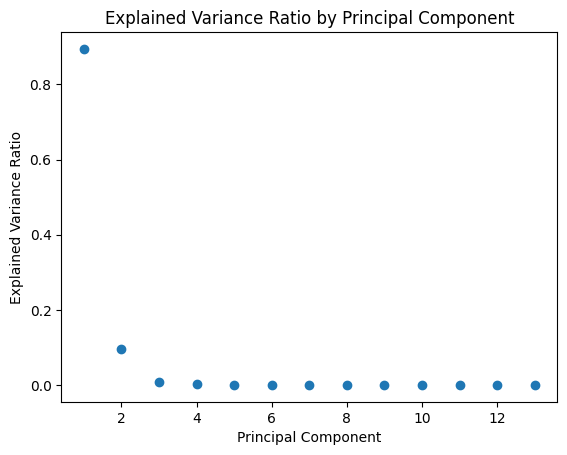

In [ ]:
lambdas = pca.explained_variance_ratio_
plt.scatter(range(1, len(lambdas) + 1), lambdas)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.show()

#### Uncomment and run the following cell to project data onto chosen number of principal components:

In [ ]:
#pca_data = pca.transform(fitdata)

#### Running ridge regression on the full dataset (fit data + element labels)
Ideally, datasets are broken up into different working electrolytes/element compounds, then modeled appropriately.
Then choose the most optimal combination given the molecule and see if it has any global maximuma for any tuning parameter.

In [ ]:
scaler = MinMaxScaler() # introducing a normalizing factor for the data as opposed to centralising, for the paretoset.
# The model still uses centred data and hence has numerical stability
pdata_norm = pdata.iloc[:, 6:]
pdata_norm = fitdata.astype(float)
pdata_norm = pd.DataFrame(
    scaler.fit_transform(pdata_norm),
    columns=pdata_norm.columns,
    index=pdata_norm.index
)

In [ ]:
front_index = paretoset.paretoset(pdata_norm, sense=["min", "max", "max", "max", "max", "max", "min", "min", "min", "min", "min", "min", "min"])
# Voltage and capacity alone are to be maximized - band gap, density and even voltage are vague measurements and depend on the application.
# A heavy duty battery for application like automobile battery is considered.
fitdata = fitdata.iloc[front_index]
pdata_front = pdata.iloc[front_index]
structure_volums = structure_volums.iloc[front_index]
structure_abc_df = structure_abc_df.iloc[front_index]

In [ ]:
pdata.shape # Checking if pareto set removed significant share of data

(5775, 19)

In [ ]:
# Get all elements in working_ion and elements columns from pdata
working_ion_mass = pdata_front["working_ion"].apply(lambda x: periodictable.elements.symbol(x).mass)
elements_mass = pdata_front["elements"].apply(lambda x: sum([periodictable.elements.symbol(el).mass for el in x.split(",")]))

#### NEW MODEL: Capacity-based scoring

Gravimetric capacity is taken as the most important parameter for ranking a battery.

#### Implementing the scoring function
Assign labels/Scoring Method- for features: valuable features, grav_capacity, delta_v (for effective cost given density), working ion, elements, nelements, structure, chemical family*


Chemical family is a little difficult to get since it's not on the materials project dataset, but if we first generate the top 100 best materials and cross check with the other dataset, we can include that in our model manually.

In [ ]:
def scoring(capacity_g, avg_v, working_ion, elements, nelements, structure_v, abc):
    a = abc["a"]
    b = abc["b"]
    c = abc["c"]
    score = capacity_g * 0.4 + avg_v * 0.4 + working_ion * 1 - elements * 0.05 + nelements * 0.1 - structure_v * 0.05 + a + b + c  #+ chemical_family * 0.05
    return score

In [ ]:
#battery_score = working_ion_mass + elements_mass*pdata["nelements"]
battery_score = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_mass, elements_mass, pdata_front["nelements"], structure_volums,structure_abc_df)
print(structure_abc_df)
# Testing to see if the model works with a randomly generated sample of fitdata and battery score
fit_train, fit_test, score_train, score_test = train_test_split(fitdata, battery_score, test_size=0.1, random_state=42)

              a          b          c
0      5.263072   5.263072   5.263072
1      4.627959   4.627959   4.627959
2      3.649504   4.306932   4.306932
3     13.947939  13.947939  13.947939
4      3.320590   3.320590   4.319788
...         ...        ...        ...
5774   7.577091   7.577091  15.136757
5775   9.393438   9.393438  10.687798
5780   5.356592   6.688287   6.687021
5781  15.448884  15.448884  15.448884
5782   4.908004   8.150276   7.194592

[3282 rows x 3 columns]


In [ ]:
ridge = linear_model.Ridge(alpha=1.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(score_pred)

0.9896087301314163


In [ ]:
best = np.where(battery_score == np.max(battery_score))[0][0]  #np.min(battery_score) was changed to max(battery_score) to obtain best capacity
print(pdata.iloc[best, 0:12])

battery_formula        Na0-1CoO2
working_ion                   Na
elements                    Co,O
nelements                    2.0
formula_charge              CoO2
formula_discharge         NaCoO2
max_delta_volume        0.095312
average_voltage         3.008841
capacity_grav         235.262167
capacity_vol         1146.437312
energy_grav           707.866355
energy_vol           3449.447102
Name: 435, dtype: object


In [ ]:

X = fitdata
y = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_mass, elements_mass, pdata_front["nelements"], structure_volums, structure_abc_df)
y = y.fillna(0)
y = y.astype(float)

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=1.0))
])

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #Find best material in predicted set
    bestmaterial.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
print("Best materials in each fold:", type(bestmaterial[0]))
bestmaterial_df = pd.DataFrame(bestmaterial)

Mean R2: 0.9727094879981906
Mean MSE: 166.67622997456152
Mean MAE: 8.29468048158561
Best materials in each fold: <class 'pandas.core.series.Series'>


In [ ]:
# Finding the equivalent material in the original pdata for each best material in bestmaterial_df by minimizing the difference between each feature of bestmaterial_df and pdata
for i in range(len(bestmaterial)):
    best_material = bestmaterial_df.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Mg1-15Ca
Best material in fold 2:
Mg1-15Ca
Best material in fold 3:
Mg1-15Ca
Best material in fold 4:
Mg1-15Ca
Best material in fold 5:
Mg0-3Cr
